In [ ]:
import pandas as pd

In [ ]:
df = pd.read_csv("german_credit_data (1).csv")

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
df.columns

Index(['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts',
       'Checking account', 'Credit amount', 'Duration', 'Purpose', 'Risk'],
      dtype='object')

In [ ]:
df.shape

(1000, 11)

In [ ]:
df.drop("Unnamed: 0", axis=1, inplace=True)


In [ ]:
print(df.isnull().sum())

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64


In [ ]:
df.fillna("unknown", inplace=True)

In [ ]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,unknown,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


In [ ]:
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder object
le = LabelEncoder()

# Encode all categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [ ]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,0
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,0


In [ ]:
# Features
X = df.drop("Risk", axis=1)

# Target
y = df["Risk"]

# Display shapes
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 9)
y shape: (1000,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Print shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (800, 9)
X_test: (200, 9)
y_train: (800,)
y_test: (200,)


In [ ]:
from sklearn.preprocessing import StandardScaler

# Create scaler object
scaler = StandardScaler()

# Fit and transform training data
X_train = scaler.fit_transform(X_train)

# Transform testing data
X_test = scaler.transform(X_test)

# Display sample scaled data
print(X_train[:5])

[[ 2.4061873   0.68205679  0.10704816 -0.12534385 -0.71478262 -1.27298066
   1.19991221  3.29708155 -1.43690208]
 [-0.22436411  0.68205679  0.10704816  1.76663884 -0.71478262  0.31700299
  -0.35962991 -0.00805096  0.0690215 ]
 [ 1.26628169  0.68205679  0.10704816  1.76663884  0.5461349   1.11199481
  -0.73354714 -1.27925578 -0.93492755]
 [-0.5751043  -1.46615357  0.10704816 -0.12534385  1.80705242  1.11199481
   0.56704953 -0.00805096 -0.93492755]
 [-1.27658468 -1.46615357  0.10704816 -0.12534385  1.80705242  1.11199481
  -0.85438835 -0.77077385  1.07297055]]


In [ ]:
scaler.fit_transform(X_train)

array([[ 2.4061873 ,  0.68205679,  0.10704816, ...,  1.19991221,
         3.29708155, -1.43690208],
       [-0.22436411,  0.68205679,  0.10704816, ..., -0.35962991,
        -0.00805096,  0.0690215 ],
       [ 1.26628169,  0.68205679,  0.10704816, ..., -0.73354714,
        -1.27925578, -0.93492755],
       ...,
       [-0.7504744 ,  0.68205679,  0.10704816, ...,  0.84360327,
         0.24619   , -0.93492755],
       [-0.92584449,  0.68205679,  0.10704816, ..., -0.64792251,
        -0.77077385,  1.07297055],
       [-1.01352954, -1.46615357,  0.10704816, ..., -0.83850636,
        -1.27925578,  1.07297055]])

In [ ]:
from sklearn.linear_model import LogisticRegression

# Create model
lr_model = LogisticRegression()

# Train model
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)

# Display predictions
print(y_pred[:10])

[0 1 0 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Precision
print("Precision:", precision_score(y_test, y_pred))

# Recall
print("Recall:", recall_score(y_test, y_pred))

# F1 Score
print("F1 Score:", f1_score(y_test, y_pred))

# Full report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.755
Precision: 0.7771084337349398
Recall: 0.9148936170212766
F1 Score: 0.8403908794788274

Classification Report:

              precision    recall  f1-score   support

           0       0.65      0.37      0.47        59
           1       0.78      0.91      0.84       141

    accuracy                           0.76       200
   macro avg       0.71      0.64      0.66       200
weighted avg       0.74      0.76      0.73       200



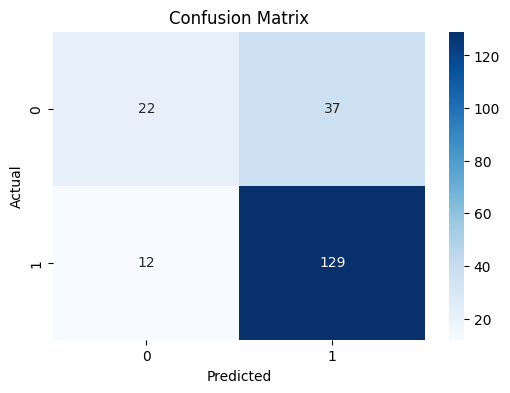

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Display first predictions
print(rf_pred[:10])

[1 1 0 1 1 1 1 1 1 1]


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, rf_pred))

# Precision
print("Precision:", precision_score(y_test, rf_pred))

# Recall
print("Recall:", recall_score(y_test, rf_pred))

# F1 Score
print("F1 Score:", f1_score(y_test, rf_pred))

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.765
Precision: 0.7901234567901234
Recall: 0.9078014184397163
F1 Score: 0.8448844884488449

Classification Report:

              precision    recall  f1-score   support

           0       0.66      0.42      0.52        59
           1       0.79      0.91      0.84       141

    accuracy                           0.77       200
   macro avg       0.72      0.67      0.68       200
weighted avg       0.75      0.77      0.75       200



            Feature  Importance
6     Credit amount    0.244211
0               Age    0.184055
7          Duration    0.149712
5  Checking account    0.126442
8           Purpose    0.093592
4   Saving accounts    0.070208
2               Job    0.054156
3           Housing    0.046789
1               Sex    0.030837


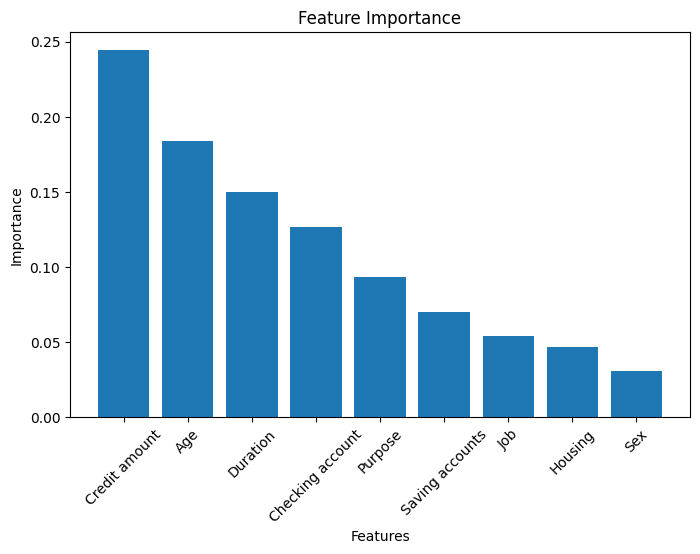

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance
importance = rf_model.feature_importances_

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Print importance
print(feature_importance)

# Plot graph
plt.figure(figsize=(8,5))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

ROC-AUC Score: 0.7799014304603917


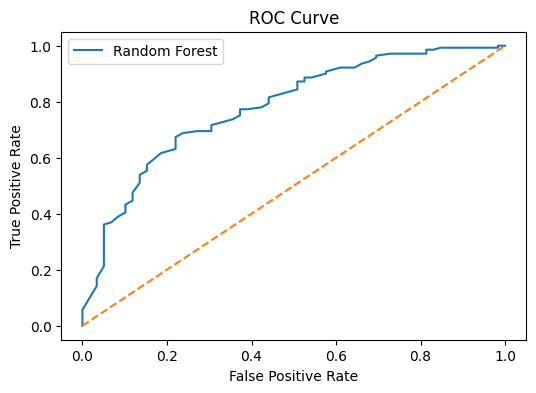

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

# Probability predictions
rf_probs = rf_model.predict_proba(X_test)[:, 1]

# ROC-AUC score
roc_score = roc_auc_score(y_test, rf_probs)

print("ROC-AUC Score:", roc_score)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, rf_probs)

# Plot
plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label='Random Forest')
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
import joblib

# Save model
joblib.dump(rf_model, "credit_scoring_model.pkl")

print("Model saved successfully.")

Model saved successfully.


In [ ]:
!pip install imbalanced-learn


In [ ]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check new class distribution
print(y_train_smote.value_counts())

Risk
0    559
1    559
Name: count, dtype: int64


In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Create model
rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train using balanced data
rf_smote.fit(X_train_smote, y_train_smote)

# Predict on original test set
smote_pred = rf_smote.predict(X_test)

# Display predictions
print(smote_pred[:10])

[1 0 0 1 1 1 1 0 1 1]


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

# Accuracy
print("Accuracy:", accuracy_score(y_test, smote_pred))

# Precision
print("Precision:", precision_score(y_test, smote_pred))

# Recall
print("Recall:", recall_score(y_test, smote_pred))

# F1 Score
print("F1 Score:", f1_score(y_test, smote_pred))

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, smote_pred))

Accuracy: 0.76
Precision: 0.8297872340425532
Recall: 0.8297872340425532
F1 Score: 0.8297872340425532

Classification Report:

              precision    recall  f1-score   support

           0       0.59      0.59      0.59        59
           1       0.83      0.83      0.83       141

    accuracy                           0.76       200
   macro avg       0.71      0.71      0.71       200
weighted avg       0.76      0.76      0.76       200

